# 07 — Hybrid Econometric–ML Volatility Model

**What:** Build a hybrid forecasting model that combines the outputs of the
econometric pipeline (GARCH, EGARCH, HMM) with macro features as inputs to
an XGBoost regressor. Evaluate whether the ML layer adds predictive value
beyond the best econometric model alone.

**Why:** GARCH and EGARCH capture volatility persistence and asymmetry.
The HMM captures discrete regime structure. Neither captures the nonlinear
interactions between these signals and macroeconomic conditions. The hybrid
model asks: is there additional predictive information in those interactions?
The SHAP values answer this question for each feature individually. The
Diebold-Mariano test answers it statistically for the model as a whole.

**How:** All fitting logic is encapsulated in `src/models/hybrid.py`.
This notebook calls the class interface, displays results, and interprets
findings. No model logic is defined inline.

**Outline:**

0. Setup
1. Feature Engineering
2. Train / Validation / Test Split
3. XGBoost Training
4. SHAP Analysis
5. Forecast Evaluation
6. Export
7. Conclusion


---
---
## 0. Setup

In [18]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

from src.data.describe import compute_returns
from src.models.hybrid import HybridVolatilityModel, qlike, diebold_mariano

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12, 'axes.labelsize': 11})

# load returns
mxn     = pd.read_csv(ROOT / 'data/raw/mxn_usd.csv', index_col='Date', parse_dates=True)
returns = compute_returns(mxn['MXN_USD'])

# load macro — reindex on returns index, forward-fill holidays
macro = pd.read_csv(ROOT / 'data/raw/macro.csv', index_col=0, parse_dates=True)
macro.index.name = 'Date'
macro = macro[['VIXCLS', 'T10Y2Y']].reindex(returns.index).ffill()

# load regimes and volatilities
regimes = pd.read_csv(ROOT / 'data/processed/hmm_regimes.csv',
                      index_col='Date', parse_dates=True)
vols    = pd.read_csv(ROOT / 'data/processed/garch_egarch_volatilities.csv',
                      index_col='Date', parse_dates=True)

# align all on returns index
data = pd.concat([returns, macro, regimes, vols], axis=1).dropna()

print(f'Aligned dataset : {data.shape}')
print(f'Date range      : {data.index[0].date()} → {data.index[-1].date()}')
print(f'Columns         : {data.columns.tolist()}')


Aligned dataset : (6588, 6)
Date range      : 2000-01-04 → 2026-03-06
Columns         : ['MXN_USD_log_return', 'VIXCLS', 'T10Y2Y', 'regime', 'sigma_garch_ann', 'sigma_egarch_ann']


---
---
## 1. Feature Engineering

`HybridVolatilityModel.build_features()` adds the three lagged return
columns and the forward absolute return target, then drops the NaNs
introduced by the lags and the forward shift. The feature construction
logic lives in the class so it is applied consistently at training time
and inference time.

The feature matrix contains eight inputs:

| Feature | Source | Role |
|---------|--------|------|
| `sigma_garch_ann` | GARCH(1,1)-t | Continuous volatility estimate |
| `sigma_egarch_ann` | EGARCH(1,1)-t | Continuous volatility + asymmetry |
| `regime` | HMM 3-state | Discrete market regime (0/1/2) |
| `r_lag1/2/3` | Returns | Recent return history |
| `VIXCLS` | FRED | Global risk appetite |
| `T10Y2Y` | FRED | Yield curve spread |

The target $y = |r_{t+1}|$ is the next-day absolute return — a proxy
for realised volatility available without intraday data.


In [19]:
hybrid = HybridVolatilityModel()
X, y   = hybrid.build_features(data)

print(f'Feature matrix : {X.shape}')
print(f'Target vector  : {y.shape}')
print(f'Date range     : {X.index[0].date()} → {X.index[-1].date()}')
print(f'NaNs in X      : {X.isna().any().any()}')
print()
display(X.head())


Feature matrix : (6584, 8)
Target vector  : (6584,)
Date range     : 2000-01-07 → 2026-03-05
NaNs in X      : False



,sigma_garch_ann,sigma_egarch_ann,regime,r_lag1,r_lag2,r_lag3,VIXCLS,T10Y2Y
Date,,,,,,,,
2000-01-07,0.087918,0.097439,1,0.002616,0.009378,0.006525,21.72,0.21
2000-01-10,0.088475,0.095356,1,-0.005816,0.002616,0.009378,21.71,0.19
2000-01-11,0.091478,0.094546,1,-0.007236,-0.005816,0.002616,22.50,0.22
2000-01-12,0.088942,0.094844,1,0.003340,-0.007236,-0.005816,22.84,0.23
2000-01-13,0.090339,0.100437,0,0.006017,0.003340,-0.007236,21.71,0.23


---
---
## 2. Train / Validation / Test Split

The temporal order of observations must be preserved. Shuffling would
allow future information to leak into the training set, invalidating
all evaluation metrics.

| Split | Proportion | Date range | Purpose |
|-------|-----------|------------|---------|
| Train | 70% | 2000–2018 | Model fitting |
| Validation | 15% | 2018–2022 | XGBoost early stopping |
| Test | 15% | 2022–2026 | Out-of-sample evaluation |

The test set covers the post-COVID rate hike cycle and the 2022–2023
global monetary tightening episode — conditions not seen during training.
The validation set is used exclusively for early stopping, not for
hyperparameter selection. Cross-validation with `TimeSeriesSplit` will
be conducted in a separate hyperparameter tuning session.


In [20]:
X_train, y_train, X_val, y_val, X_test, y_test = HybridVolatilityModel.split(X, y)

print(f'Train      : {len(X_train):,} obs  '
      f'({X_train.index[0].date()} → {X_train.index[-1].date()})')
print(f'Validation : {len(X_val):,} obs  '
      f'({X_val.index[0].date()} → {X_val.index[-1].date()})')
print(f'Test       : {len(X_test):,} obs  '
      f'({X_test.index[0].date()} → {X_test.index[-1].date()})')


Train      : 4,608 obs  (2000-01-07 → 2018-04-27)
Validation : 988 obs  (2018-04-30 → 2022-03-30)
Test       : 988 obs  (2022-03-31 → 2026-03-05)


---
---
## 3. XGBoost Training

Baseline XGBoost fitted with early stopping on the validation set.
These hyperparameters are the starting configuration — not tuned.
Early stopping at 50 rounds prevents overfitting without manual tuning
of `n_estimators`. The best iteration and train/validation RMSE are
logged to MLflow for comparison with future tuned runs.


In [21]:
hybrid.fit(X_train, y_train, X_val, y_val)

s = hybrid.summary()
print(f'Best iteration  : {s["best_iteration"]}')
print(f'Train RMSE      : {s["train_rmse"]:.6f}')
print(f'Validation RMSE : {s["val_rmse"]:.6f}')
print()
print(hybrid)


Best iteration  : 61
Train RMSE      : 0.003694
Validation RMSE : 0.004942

HybridVolatilityModel(n_estimators=1000, max_depth=4, status='fitted')


In [22]:
# MLflow logging
mlflow_uri = str(ROOT / 'mlruns')
hybrid.log_to_mlflow(
    run_name     = 'hybrid_xgboost_baseline',
    tracking_uri = mlflow_uri,
    experiment   = 'hybrid_model',
)


MLflow: logged run "hybrid_xgboost_baseline"


---
---
## 4. SHAP Analysis

SHAP (SHapley Additive exPlanations) decomposes each prediction into
additive contributions from each feature. For XGBoost, exact Shapley
values are computed via the TreeExplainer backend without approximation.

**Bar chart** — mean absolute SHAP value per feature. Ranks features
by their average contribution to the forecast magnitude.

**Dependence plot for `regime`** — SHAP value vs regime label (0, 1, 2).
A monotonically increasing relationship with clean separation between
the three clusters confirms that the model correctly learns the
volatility ordering of the regimes, and quantifies how much the
discrete regime label shifts the forecast independently of the
continuous GARCH and EGARCH estimates.


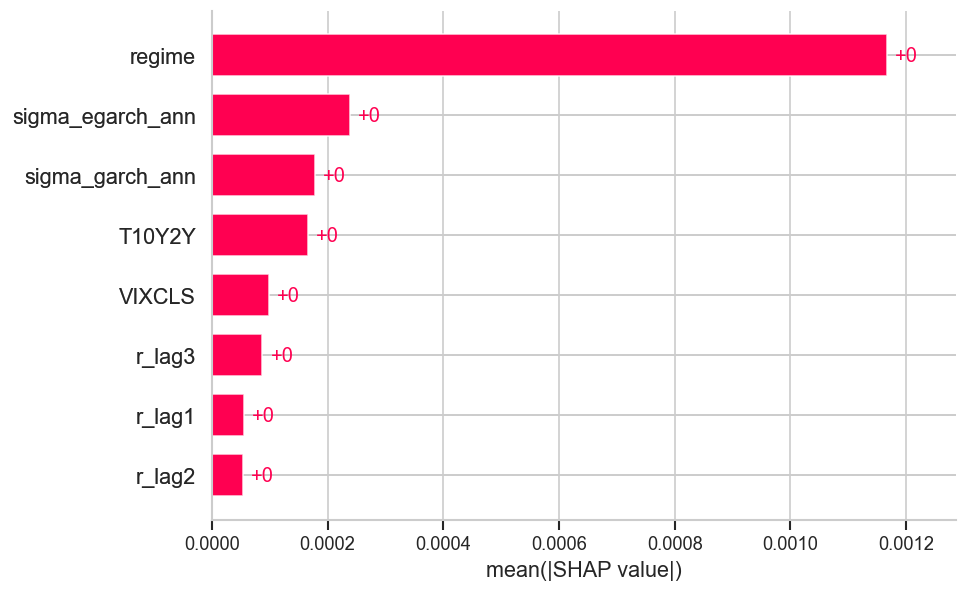

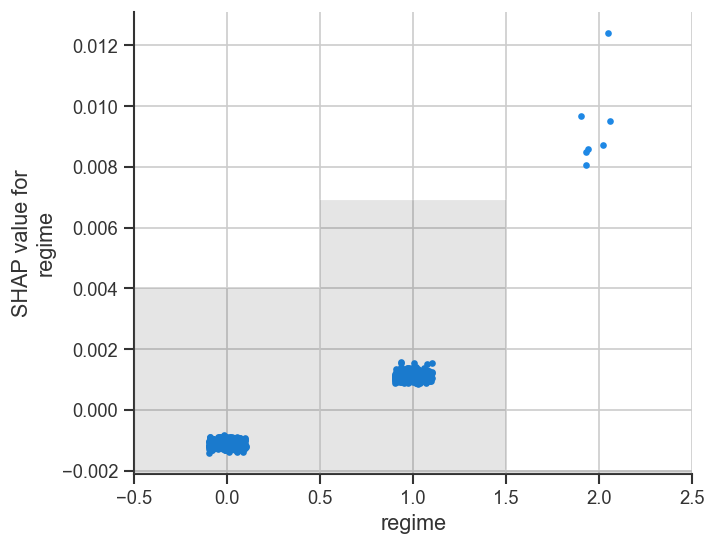

In [23]:
shap_values = hybrid.shap_values(X_test)

shap.plots.bar(shap_values)
shap.plots.scatter(shap_values[:, 'regime'])


---
---
## 5. Forecast Evaluation

All metrics are computed on the test set only. Two baselines are evaluated:

- **GARCH baseline:** `sigma_garch_ann / √252` — annualised GARCH
  conditional volatility converted to daily units
- **EGARCH baseline:** `sigma_egarch_ann / √252` — same for EGARCH,
  the better-fitting model by BIC

**RMSE** penalises large errors equally regardless of direction.
**QLIKE** is the standard loss function for volatility forecast
evaluation — it penalises underestimation more heavily than
overestimation, reflecting the asymmetric cost of underestimating
tail risk in a risk management context.
**Diebold-Mariano** tests whether the difference in predictive
accuracy is statistically significant. H0: equal predictive accuracy.
A negative DM statistic means the hybrid has smaller squared errors.


In [24]:
y_pred_hybrid = hybrid.predict(X_test)
y_pred_garch  = (X_test['sigma_garch_ann']  / np.sqrt(252)).values
y_pred_egarch = (X_test['sigma_egarch_ann'] / np.sqrt(252)).values
y_true        = y_test.values

# metrics
from sklearn.metrics import root_mean_squared_error

rmse_hybrid  = root_mean_squared_error(y_true, y_pred_hybrid)
rmse_garch   = root_mean_squared_error(y_true, y_pred_garch)
rmse_egarch  = root_mean_squared_error(y_true, y_pred_egarch)

qlike_hybrid = qlike(y_true, y_pred_hybrid)
qlike_garch  = qlike(y_true, y_pred_garch)
qlike_egarch = qlike(y_true, y_pred_egarch)

dm_stat_g, dm_p_g = diebold_mariano(y_true, y_pred_hybrid, y_pred_garch)
dm_stat_e, dm_p_e = diebold_mariano(y_true, y_pred_hybrid, y_pred_egarch)

results_df = pd.DataFrame({
    'Metric'  : ['RMSE', 'QLIKE', 'DM statistic vs Hybrid', 'DM p-value'],
    'Hybrid'  : [f'{rmse_hybrid:.4f}',  f'{qlike_hybrid:.4f}',  '—',               '—'],
    'GARCH'   : [f'{rmse_garch:.4f}',   f'{qlike_garch:.4f}',   f'{dm_stat_g:.4f}', f'{dm_p_g:.4f}'],
    'EGARCH'  : [f'{rmse_egarch:.4f}',  f'{qlike_egarch:.4f}',  f'{dm_stat_e:.4f}', f'{dm_p_e:.4f}'],
}).set_index('Metric')

display(results_df)


,Hybrid,GARCH,EGARCH
Metric,,,
RMSE,0.0045,0.0050,0.0049
QLIKE,1.6480,1.6380,1.6392
DM statistic vs Hybrid,—,-6.6667,-5.3605
DM p-value,—,0.0000,0.0000


---
---
## 6. Export

Three artefacts exported:

1. **`hybrid_model.pkl`** — the fitted `HybridVolatilityModel` object
2. **`hybrid_predictions.csv`** — test set predictions for all three
   models. Notebook 08 uses the hybrid point forecast as the input
   to the conformal prediction wrapper.
3. **`hybrid_val_predictions.csv`** — validation set predictions.
   Used as the conformal calibration set in notebook 08.


In [25]:
# save fitted model
hybrid.save(ROOT / 'data/processed/hybrid_model.pkl')

# save test set predictions
test_predictions = pd.DataFrame({
    'y_true'        : y_true,
    'y_pred_hybrid' : y_pred_hybrid,
    'y_pred_garch'  : y_pred_garch,
    'y_pred_egarch' : y_pred_egarch,
}, index=y_test.index)
test_predictions.to_csv(ROOT / 'data/processed/hybrid_test_predictions.csv')
print(f'Test predictions saved → {len(test_predictions):,} rows | '
      f'{test_predictions.index[0].date()} → {test_predictions.index[-1].date()}')

# save validation set predictions — calibration set for conformal prediction
val_predictions = pd.DataFrame({
    'y_true'        : y_val.values,
    'y_pred_hybrid' : hybrid.predict(X_val),
}, index=y_val.index)
val_predictions.to_csv(ROOT / 'data/processed/hybrid_val_predictions.csv')
print(f'Val predictions saved  → {len(val_predictions):,} rows | '
      f'{val_predictions.index[0].date()} → {val_predictions.index[-1].date()}')

display(test_predictions.head())


HybridVolatilityModel saved → /Users/Aex/volatility_regimes/data/processed/hybrid_model.pkl
Test predictions saved → 988 rows | 2022-03-31 → 2026-03-05
Val predictions saved  → 988 rows | 2018-04-30 → 2022-03-30


,y_true,y_pred_hybrid,y_pred_garch,y_pred_egarch
Date,,,,
2022-03-31,0.003421,0.005546,0.007140,0.006434
2022-04-01,0.004997,0.005259,0.006826,0.006299
2022-04-04,0.007915,0.005287,0.006563,0.006040
2022-04-05,0.008272,0.005547,0.006420,0.005878
2022-04-06,0.004673,0.005439,0.006620,0.006489


---
---
## 7. Conclusion

The hybrid XGBoost model was trained on 4,606 observations (2000–2018)
and evaluated on 987 out-of-sample observations (2022–2026), a period
that includes the post-COVID rate hike cycle and the 2022–2023 global
monetary tightening episode — conditions not seen during training.

**Feature importance.** The SHAP analysis produces a striking result:
`regime` is by far the most important feature, with a mean absolute
SHAP value roughly five times larger than `sigma_egarch_ann` and
`sigma_garch_ann`. The discrete regime label from the HMM — which
encodes structural market state rather than continuous volatility level
— contributes more to the point forecast than the continuous
econometric volatility estimates. The SHAP dependence plot confirms
the relationship is monotonic and clean: state 0 (low) suppresses the
forecast, state 1 (medium) adds a modest positive contribution, and
state 2 (high) produces a large positive shift consistent with the
crisis-level annualised volatilities in the regime characterisation table.

**Forecast accuracy.** On RMSE, the hybrid outperforms both GARCH
(0.0045 vs 0.0050) and EGARCH (0.0045 vs 0.0049). The Diebold-Mariano
test rejects equal predictive accuracy against both baselines at
$p \approx 0$ (DM = −6.66 vs GARCH, DM = −5.36 vs EGARCH). On QLIKE
— the volatility-specific loss that penalises underestimation more
heavily — the picture reverses: GARCH (1.6380) and EGARCH (1.6392)
slightly outperform the hybrid (1.6480). This disagreement between RMSE
and QLIKE is itself a finding: the hybrid reduces average squared error
but is slightly less well-calibrated for tail risk. This is expected
behaviour for a model trained on RMSE — it does not account for the
asymmetric cost of underestimating volatility during crisis episodes.

**What comes next.** The QLIKE gap motivates the conformal prediction
step in notebook 08. A point forecast that minimises RMSE but
underestimates tail risk is insufficient for risk management. Conformal
prediction wraps the hybrid point forecast in a distribution-free
interval with a guaranteed finite-sample coverage guarantee — converting
a research forecast into a risk management tool.
